# Epileptic Seizure Detection from EEG using a CNN-LSTM

**Goal:** Detect epileptic seizures from single-channel EEG signals.

**Dataset:** UCI *Epileptic Seizure Recognition* (Bonn EEG corpus, reshaped).
- 11,500 samples, each row = **178 EEG readings** (~1 second at 178 Hz).
- Column `y` has 5 balanced classes (2,300 each):
  - **1** = seizure activity (ictal)
  - **2** = tumour-area EEG (non-seizure)
  - **3** = healthy-area EEG (non-seizure)
  - **4** = eyes closed (non-seizure)
  - **5** = eyes open (non-seizure)

We frame this as a **binary problem**: `1` (seizure) vs `0` (non-seizure = classes 2-5),
which gives a realistic ~20% / 80% imbalance.

**Pipeline:** load → explore → preprocess → baseline (Random Forest) → **CNN-LSTM** → evaluate → save.


## 0. Setup

The CNN-LSTM needs TensorFlow/Keras. If it is not installed, run the cell below once
(uncomment it). Everything up to the baseline model works without TensorFlow.

In [1]:
# Run once if TensorFlow is not installed, then restart the kernel.
# %pip install tensorflow scikit-learn matplotlib seaborn pandas numpy

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4)
print("Libraries loaded.")

Libraries loaded.


## 1. Load the data

The notebook lives in `epilepsy_detection/`; the CSV sits one level up on the Desktop.
The resolver below tries a few common locations so the notebook is portable.

In [3]:
CANDIDATE_PATHS = [
    "Epileptic Seizure TUH dataset.csv",
    "../Epileptic Seizure TUH dataset.csv",
    "data/Epileptic Seizure TUH dataset.csv",
]

DATA_PATH = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find the CSV. Set DATA_PATH manually to the dataset location.")

df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
df.head()

Loaded: ../Epileptic Seizure TUH dataset.csv
Shape: (11500, 180)


,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


In [4]:
# The first column is just a sample id string ("Unnamed"); drop it.
if "Unnamed" in df.columns:
    df = df.drop(columns=["Unnamed"])
elif df.columns[0].lower().startswith("unnamed"):
    df = df.drop(columns=df.columns[0])

print("Feature columns:", df.shape[1] - 1)
print("Any missing values?", df.isnull().values.any())
df.describe().T.head()

Feature columns: 178
Any missing values? False


,count,mean,std,min,25%,50%,75%,max
X1,11500.0,-11.581391,165.626284,-1839.0,-54.0,-8.0,34.0,1726.0
X2,11500.0,-10.911565,166.059609,-1838.0,-55.0,-8.0,35.0,1713.0
X3,11500.0,-10.187130,163.524317,-1835.0,-54.0,-7.0,36.0,1697.0
X4,11500.0,-9.143043,161.269041,-1845.0,-54.0,-8.0,36.0,1612.0
X5,11500.0,-8.009739,160.998007,-1791.0,-54.0,-8.0,35.0,1518.0


## 2. Exploratory data analysis

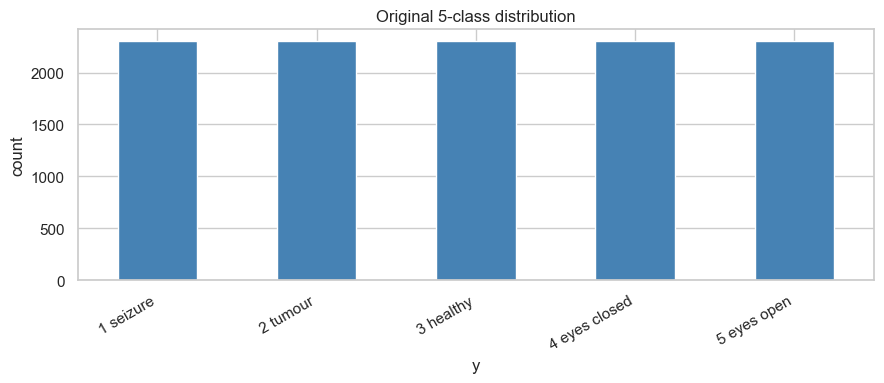

y
1 seizure        2300
2 tumour         2300
3 healthy        2300
4 eyes closed    2300
5 eyes open      2300
Name: count, dtype: int64

In [5]:
# Original 5-class distribution
class_names = {1: "1 seizure", 2: "2 tumour", 3: "3 healthy",
               4: "4 eyes closed", 5: "5 eyes open"}
counts = df["y"].map(class_names).value_counts().sort_index()

ax = counts.plot(kind="bar", color="steelblue")
ax.set_title("Original 5-class distribution")
ax.set_ylabel("count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
counts

label
0    9200
1    2300
Name: count, dtype: int64
Seizure fraction: 20.0%


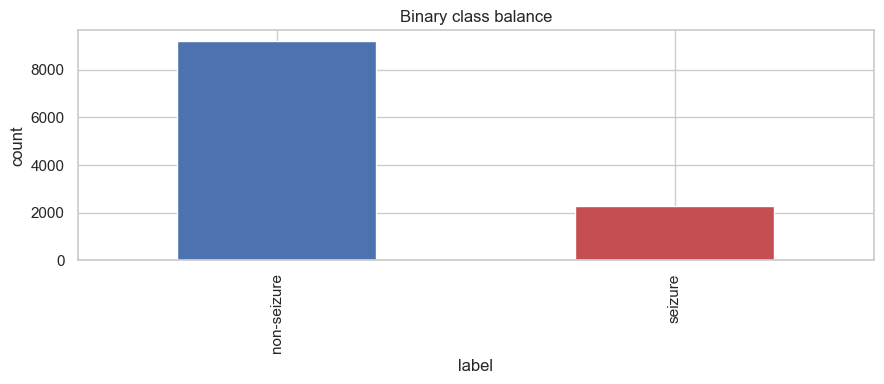

In [6]:
# Binary target: 1 = seizure, 0 = everything else
df["label"] = (df["y"] == 1).astype(int)
dist = df["label"].value_counts()
print(dist)
print(f"Seizure fraction: {df['label'].mean():.1%}")

df["label"].map({0: "non-seizure", 1: "seizure"}).value_counts().plot(
    kind="bar", color=["#4c72b0", "#c44e52"], title="Binary class balance")
plt.ylabel("count"); plt.tight_layout(); plt.show()

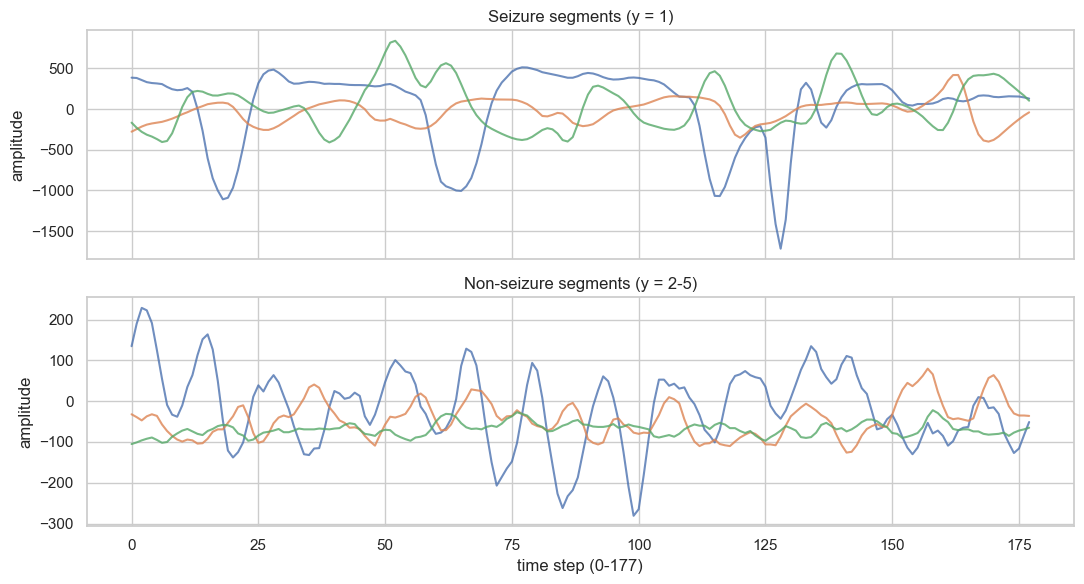

In [7]:
# Compare example EEG waveforms: seizure vs non-seizure
feature_cols = [c for c in df.columns if c.startswith("X")]

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for i in range(3):
    axes[0].plot(df[df.label == 1][feature_cols].iloc[i].values, alpha=0.8)
    axes[1].plot(df[df.label == 0][feature_cols].iloc[i].values, alpha=0.8)
axes[0].set_title("Seizure segments (y = 1)")
axes[1].set_title("Non-seizure segments (y = 2-5)")
axes[1].set_xlabel("time step (0-177)")
for a in axes: a.set_ylabel("amplitude")
plt.tight_layout(); plt.show()

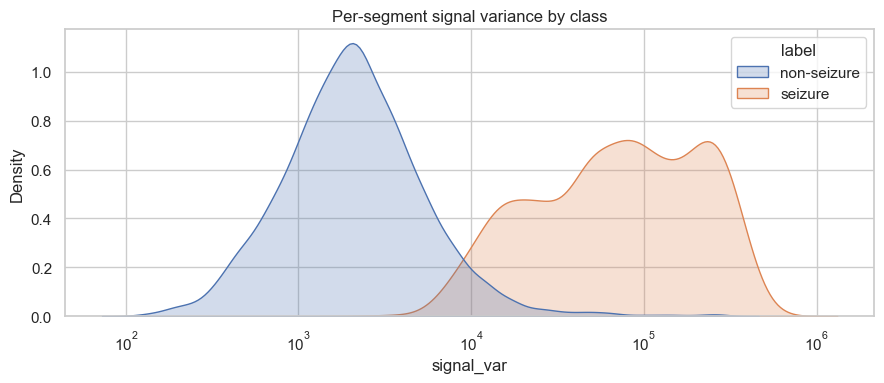

In [8]:
# Signal energy (variance) is a strong hand-crafted discriminator
df["signal_var"] = df[feature_cols].var(axis=1)
sns.kdeplot(data=df, x="signal_var", hue=df["label"].map({0:"non-seizure",1:"seizure"}),
            log_scale=True, fill=True, common_norm=False)
plt.title("Per-segment signal variance by class")
plt.tight_layout(); plt.show()

## 3. Preprocessing

1. Split features `X` (178 columns) and binary target `y`.
2. Stratified train / validation / test split.
3. Standardize with statistics learned on the **training set only** (no leakage).
4. Reshape to `(samples, 178, 1)` — a length-178 sequence with 1 channel — for the CNN-LSTM.

In [9]:
X = df[feature_cols].values.astype("float32")
y = df["label"].values.astype("int32")

# 70% train, 15% val, 15% test, stratified to preserve the seizure ratio
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=RANDOM_STATE)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# 3D tensors for the sequence model
X_train_seq = X_train_s[..., np.newaxis]
X_val_seq   = X_val_s[..., np.newaxis]
X_test_seq  = X_test_s[..., np.newaxis]

print("train/val/test:", X_train_seq.shape, X_val_seq.shape, X_test_seq.shape)
print("train seizure %:", y_train.mean().round(3),
      "| test seizure %:", y_test.mean().round(3))

train/val/test: (8050, 178, 1) (1725, 178, 1) (1725, 178, 1)
train seizure %: 0.2 | test seizure %: 0.2


## 4. Baseline model (Random Forest)

A quick classical baseline on the flat 178 features. This sets the bar the CNN-LSTM
should beat and runs without any deep-learning framework.

In [10]:
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                            n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(X_train_s, y_train)

rf_proba = rf.predict_proba(X_test_s)[:, 1]
rf_pred = (rf_proba >= 0.5).astype(int)

print("Random Forest — test set")
print(classification_report(y_test, rf_pred, target_names=["non-seizure", "seizure"]))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_proba), 4))

Random Forest — test set
              precision    recall  f1-score   support

 non-seizure       0.97      0.99      0.98      1380
     seizure       0.96      0.87      0.91       345

    accuracy                           0.97      1725
   macro avg       0.97      0.93      0.95      1725
weighted avg       0.97      0.97      0.97      1725

ROC-AUC: 0.9952


## 5. CNN-LSTM model

**Architecture intuition:**
- **1D convolutions** learn local EEG shapes (spikes, sharp waves) and downsample.
- The **LSTM** models how those features evolve across the 1-second sequence.
- A **dense head** with dropout produces the seizure probability.

Class imbalance is handled with `class_weight`.

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

tf.random.set_seed(RANDOM_STATE)

def build_cnn_lstm(input_len=178):
    model = models.Sequential([
        layers.Input(shape=(input_len, 1)),

        layers.Conv1D(64, 5, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),

        layers.Conv1D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),

        layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
        layers.Dropout(0.3),
        layers.Bidirectional(layers.LSTM(32)),
        layers.Dropout(0.3),

        layers.Dense(64, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=["accuracy",
                           tf.keras.metrics.AUC(name="auc"),
                           tf.keras.metrics.Precision(name="precision"),
                           tf.keras.metrics.Recall(name="recall")])
    return model

model = build_cnn_lstm()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 178, 64)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 178, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 89, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 89, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 89, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 44, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 44, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 44, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 170,113 (664.50 KB)

 Trainable params: 169,729 (663.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [12]:
# Weight the rare seizure class up
n_neg, n_pos = np.bincount(y_train)
class_weight = {0: 1.0, 1: n_neg / n_pos}
print("class_weight:", class_weight)

cbs = [
    callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=8,
                            restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=4, min_lr=1e-5),
]

history = model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=40, batch_size=64,
    class_weight=class_weight,
    callbacks=cbs, verbose=1)

class_weight: {0: 1.0, 1: 4.0}
Epoch 1/40


  1/126 ━━━━━━━━━━━━━━━━━━━━ 25:08 12s/step - accuracy: 0.6562 - auc: 0.2882 - loss: 1.1415 - precision: 0.0769 - recall: 0.0909

  2/126 ━━━━━━━━━━━━━━━━━━━━ 16s 132ms/step - accuracy: 0.7109 - auc: 0.5839 - loss: 1.0163 - precision: 0.2500 - recall: 0.3810

  3/126 ━━━━━━━━━━━━━━━━━━━━ 16s 133ms/step - accuracy: 0.7812 - auc: 0.7528 - loss: 0.9587 - precision: 0.4255 - recall: 0.5714

  4/126 ━━━━━━━━━━━━━━━━━━━━ 15s 129ms/step - accuracy: 0.8125 - auc: 0.8271 - loss: 0.9265 - precision: 0.5079 - recall: 0.6531

...

123/126 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9975 - auc: 0.9999 - loss: 0.0115 - precision: 0.9893 - recall: 0.9981

124/126 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9974 - auc: 0.9999 - loss: 0.0118 - precision: 0.9894 - recall: 0.9975

125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9974 - auc: 0.9999 - loss: 0.0117 - precision: 0.9895 - recall: 0.9975

126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9974 - auc: 0.9999 - loss: 0.0116 - precision: 0.9895 - recall: 0.9975

126/126 ━━━━━━━━━━━━━━━━━━━━ 13s 102ms/step - accuracy: 0.9974 - auc: 0.9999 - loss: 0.0116 - precision: 0.9895 - recall: 0.9975 - val_accuracy: 0.9878 - val_auc: 0.9947 - val_loss: 0.0470 - val_precision: 0.9655 - val_recall: 0.9739 - learning_rate: 5.0000e-04


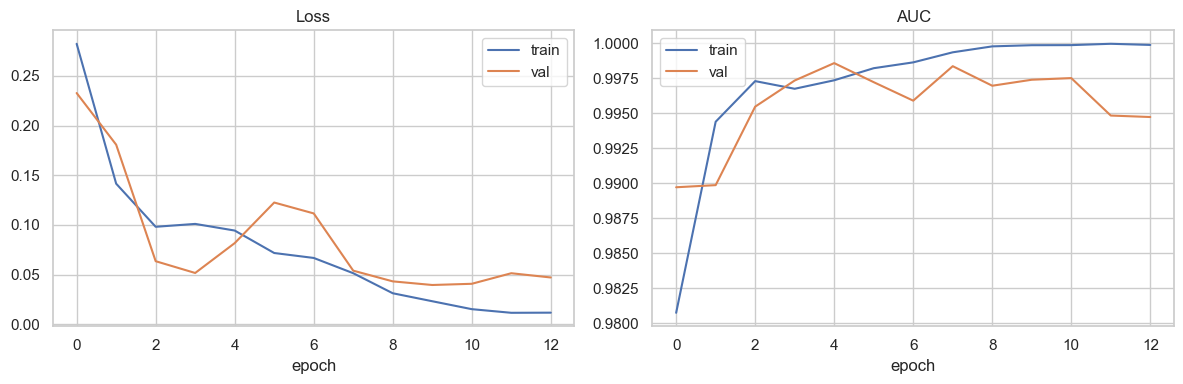

In [13]:
# Training curves
h = history.history
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(h["loss"], label="train"); ax[0].plot(h["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(h["auc"], label="train"); ax[1].plot(h["val_auc"], label="val")
ax[1].set_title("AUC"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

## 6. Evaluation on the held-out test set

In [14]:
cnn_proba = model.predict(X_test_seq, verbose=0).ravel()
cnn_pred = (cnn_proba >= 0.5).astype(int)

print("CNN-LSTM — test set")
print(classification_report(y_test, cnn_pred, target_names=["non-seizure", "seizure"]))
print("ROC-AUC:", round(roc_auc_score(y_test, cnn_proba), 4))

CNN-LSTM — test set
              precision    recall  f1-score   support

 non-seizure       1.00      0.97      0.98      1380
     seizure       0.88      0.99      0.93       345

    accuracy                           0.97      1725
   macro avg       0.94      0.98      0.96      1725
weighted avg       0.97      0.97      0.97      1725

ROC-AUC: 0.9982


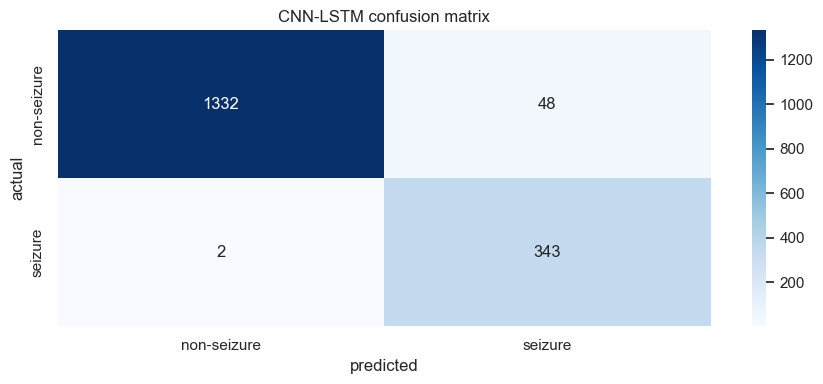

In [15]:
# Confusion matrix
cm = confusion_matrix(y_test, cnn_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["non-seizure", "seizure"],
            yticklabels=["non-seizure", "seizure"])
plt.xlabel("predicted"); plt.ylabel("actual")
plt.title("CNN-LSTM confusion matrix")
plt.tight_layout(); plt.show()

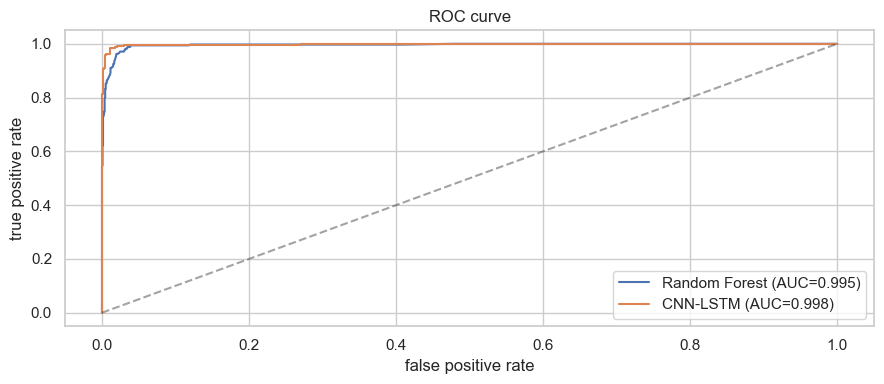

In [16]:
# ROC comparison: baseline vs CNN-LSTM
for name, proba in [("Random Forest", rf_proba), ("CNN-LSTM", cnn_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("false positive rate"); plt.ylabel("true positive rate")
plt.title("ROC curve"); plt.legend(); plt.tight_layout(); plt.show()

### Threshold tuning

In a clinical setting, **missing a seizure (false negative) is worse than a false alarm**.
The precision-recall trade-off below helps pick an operating threshold that favours recall.

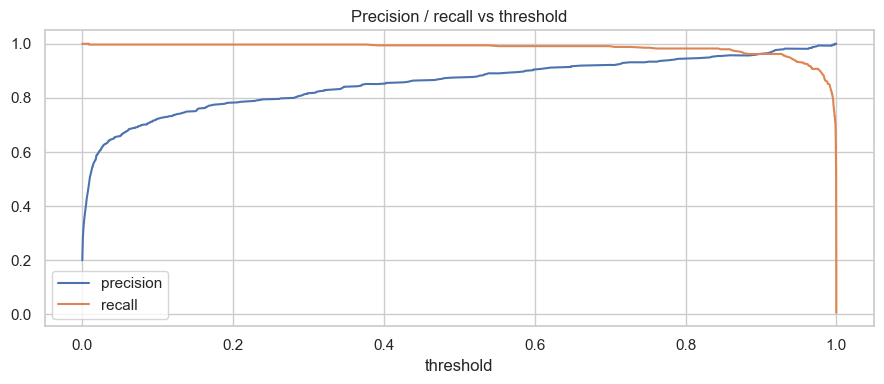

Threshold for recall>=0.95: 0.937
              precision    recall  f1-score   support

 non-seizure       0.99      1.00      0.99      1380
     seizure       0.98      0.95      0.97       345

    accuracy                           0.99      1725
   macro avg       0.98      0.97      0.98      1725
weighted avg       0.99      0.99      0.99      1725



In [17]:
prec, rec, thr = precision_recall_curve(y_test, cnn_proba)
plt.plot(thr, prec[:-1], label="precision")
plt.plot(thr, rec[:-1], label="recall")
plt.xlabel("threshold"); plt.title("Precision / recall vs threshold")
plt.legend(); plt.tight_layout(); plt.show()

# Example: pick the lowest threshold that keeps recall >= 0.95
target_recall = 0.95
ok = np.where(rec[:-1] >= target_recall)[0]
if len(ok):
    t = thr[ok[-1]]
    pred_t = (cnn_proba >= t).astype(int)
    print(f"Threshold for recall>={target_recall}: {t:.3f}")
    print(classification_report(y_test, pred_t,
          target_names=["non-seizure", "seizure"]))

## 7. Save the trained model

In [18]:
os.makedirs("artifacts", exist_ok=True)
model.save("artifacts/cnn_lstm_seizure.keras")

import joblib
joblib.dump(scaler, "artifacts/scaler.joblib")
print("Saved model and scaler to ./artifacts/")

Saved model and scaler to ./artifacts/


## 8. Detecting seizures in **new** EEG data

The trained model is now reusable. Given any new 1-second EEG segment (178 samples),
we load the saved model + scaler and get a seizure probability back — no retraining needed.
This is the core of a real seizure-alert system.

In [19]:
# Reload the saved artifacts (so this section works on its own too)
import joblib
saved_model = tf.keras.models.load_model("artifacts/cnn_lstm_seizure.keras")
saved_scaler = joblib.load("artifacts/scaler.joblib")

def predict_eeg(segments, threshold=0.5):
    """segments: array-like of shape (178,) or (n, 178). Returns a results DataFrame."""
    Xnew = np.asarray(segments, dtype="float32")
    if Xnew.ndim == 1:
        Xnew = Xnew[np.newaxis, :]
    if Xnew.shape[1] != 178:
        raise ValueError(f"Each segment must have 178 samples, got {Xnew.shape[1]}.")
    Xs = saved_scaler.transform(Xnew)[..., np.newaxis]
    proba = saved_model.predict(Xs, verbose=0).ravel()
    pred = (proba >= threshold).astype(int)
    return pd.DataFrame({
        "seizure_probability": proba.round(4),
        "prediction": np.where(pred == 1, "SEIZURE", "non-seizure"),
    })

print("Inference helper ready.")

Inference helper ready.


**Sanity check** — feed the model a few segments we know the true answer for
(3 real seizures + 3 non-seizures) and confirm it gets them right.

In [20]:
known_seiz = df[df.label == 1][feature_cols].sample(3, random_state=7)
known_non  = df[df.label == 0][feature_cols].sample(3, random_state=7)
check = pd.concat([known_seiz, known_non])
truth = ["seizure"]*3 + ["non-seizure"]*3

out = predict_eeg(check.values)
out.insert(0, "true_label", truth)
out

,true_label,seizure_probability,prediction
0,seizure,0.9998,SEIZURE
1,seizure,0.9999,SEIZURE
2,seizure,0.9982,SEIZURE
3,non-seizure,0.5504,SEIZURE
4,non-seizure,0.0008,non-seizure
5,non-seizure,0.0003,non-seizure


**Detecting on a new file** — drop a CSV next to the notebook where each row is
178 EEG samples, set `NEW_DATA`, and run. A ready-made `sample_new_eeg.csv`
(6 unlabelled segments) is included so this runs out of the box.

In [21]:
NEW_DATA = "sample_new_eeg.csv"   # <-- replace with your own recording

if os.path.exists(NEW_DATA):
    new_df = pd.read_csv(NEW_DATA)
    # keep only the 178 signal columns (drop any id / label columns)
    num = new_df.select_dtypes("number")
    for lbl in ("y", "label"):
        if lbl in num.columns:
            num = num.drop(columns=lbl)
    num = num.iloc[:, :178]
    results = predict_eeg(num.values)
    n = int((results["prediction"] == "SEIZURE").sum())
    print(f"Analysed {len(results)} segment(s) from '{NEW_DATA}' - "
          f"detected {n} seizure(s).")
    display(results)
else:
    print(f"'{NEW_DATA}' not found. Put your CSV next to the notebook and rerun.")

Analysed 6 segment(s) from 'sample_new_eeg.csv' - detected 4 seizure(s).


,seizure_probability,prediction
0,0.9982,SEIZURE
1,0.9999,SEIZURE
2,0.0008,non-seizure
3,0.9998,SEIZURE
4,0.5504,SEIZURE
5,0.0003,non-seizure


> You can also run this from a terminal without opening the notebook:
> ```
> python predict.py sample_new_eeg.csv
> ```
> It prints the per-segment verdict and writes `predictions.csv`.

## 9. Summary & next steps

**What we built**
- A reproducible pipeline that classifies 1-second EEG segments as seizure / non-seizure.
- A Random Forest baseline and a Bidirectional **CNN-LSTM** deep model.
- Imbalance handling (class weights) and clinically-aware threshold tuning.

**Ideas to push further**
- **k-fold cross-validation** for a more robust performance estimate.
- Add **spectral features** (band power, spectrogram) or feed a 2-D spectrogram to a 2-D CNN.
- Try the full **5-class** problem instead of binary.
- **Patient-independent** splits (group by subject) to test real-world generalization.
- Export to **TensorFlow Lite** / ONNX for on-device seizure alerting.
